In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('C:/Users/dilus/Downloads/DSPL docs/Hotel-A-validation.csv')
df.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,45716350,M,56,caucasian,Grad,<25K,West,Resort,8/31/2016,9/2/2016,...,HB,No,No,No Deposit,Agent,No,No-Show,Yes,15,192
1,88857401,M,60,Latino,College,25K --50K,West,Resort,8/31/2016,9/4/2016,...,FB,Yes,No,No Deposit,Online,Yes,Canceled,No,0,187
2,16074440,F,58,Asian American,College,<25K,North,Airport Hotels,9/1/2016,9/2/2016,...,FB,No,No,No Deposit,Direct,No,Canceled,Yes,10,227
3,10992124,F,23,Latino,College,25K --50K,East,Airport Hotels,8/31/2016,9/2/2016,...,FB,Yes,No,Refundable,Direct,No,Check-In,Yes,25,189
4,15934351,F,47,Asian American,College,25K --50K,South,City Hotel,8/31/2016,9/1/2016,...,HB,Yes,No,No Deposit,Online,Yes,Check-In,Yes,10,218


In [5]:
# Basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2749 entries, 0 to 2748
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          2749 non-null   int64 
 1   Gender                  2749 non-null   object
 2   Age                     2749 non-null   int64 
 3   Ethnicity               2749 non-null   object
 4   Educational_Level       2749 non-null   object
 5   Income                  2749 non-null   object
 6   Country_region          2749 non-null   object
 7   Hotel_Type              2749 non-null   object
 8   Expected_checkin        2749 non-null   object
 9   Expected_checkout       2749 non-null   object
 10  Booking_date            2749 non-null   object
 11  Adults                  2749 non-null   int64 
 12  Children                2749 non-null   int64 
 13  Babies                  2749 non-null   int64 
 14  Meal_Type               2749 non-null   object
 15  Vist

In [6]:
# Check for missing values
df.isnull().sum()

Reservation-id            0
Gender                    0
Age                       0
Ethnicity                 0
Educational_Level         0
Income                    0
Country_region            0
Hotel_Type                0
Expected_checkin          0
Expected_checkout         0
Booking_date              0
Adults                    0
Children                  0
Babies                    0
Meal_Type                 0
Visted_Previously         0
Previous_Cancellations    0
Deposit_type              0
Booking_channel           0
Required_Car_Parking      0
Reservation_Status        0
Use_Promotion             0
Discount_Rate             0
Room_Rate                 0
dtype: int64

In [7]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
# Summary statistics for all numeric columns
df.describe()

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,2.749000e+03,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000,2749.000000
mean,4.991827e+07,44.196799,2.336850,1.740633,0.333940,12.484540,173.742452
std,2.888011e+07,15.212212,1.185808,0.724913,0.566997,11.166182,43.880178
min,1.430000e+02,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.484313e+07,31.000000,1.000000,1.000000,0.000000,5.000000,136.000000
50%,4.932876e+07,44.000000,2.000000,2.000000,0.000000,10.000000,173.000000
75%,7.471297e+07,57.000000,3.000000,2.000000,1.000000,20.000000,212.000000
max,9.998849e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000


In [9]:
# See what categories exist in each text column
cat_cols = ['Gender', 'Hotel_Type', 'Booking_channel', 'Deposit_type',
            'Reservation_Status', 'Meal_Type', 'Income', 'Country_region']

for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

Gender: ['M' 'F']
Hotel_Type: ['Resort' 'Airport Hotels' 'City Hotel']
Booking_channel: ['Agent' 'Online' 'Direct']
Deposit_type: ['No Deposit' 'Refundable' 'Non-Refundable']
Reservation_Status: ['No-Show' 'Canceled' 'Check-In']
Meal_Type: ['HB' 'FB' 'BB']
Income: ['<25K' '25K --50K' '50K -- 100K' '>100K']
Country_region: ['West' 'North' 'East' 'South']


In [10]:
# Convert date columns from text to actual dates
df['Expected_checkin']  = pd.to_datetime(df['Expected_checkin'])
df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'])
df['Booking_date']      = pd.to_datetime(df['Booking_date'])

print('Dates converted ✓')

Dates converted ✓


In [11]:
# How many nights did they stay?
df['Length_of_Stay'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

# How many days in advance did they book?
df['Lead_Time_Days'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

# Total number of guests per booking
df['Total_Guests'] = df['Adults'] + df['Children'] + df['Babies']

# Potential revenue per booking (room rate x nights)
df['Potential_Revenue'] = df['Room_Rate'] * df['Length_of_Stay']

print('New columns created ✓')
df[['Length_of_Stay', 'Lead_Time_Days', 'Total_Guests', 'Potential_Revenue']].head()

New columns created ✓


,Length_of_Stay,Lead_Time_Days,Total_Guests,Potential_Revenue
0,2,195,4,384
1,4,175,4,748
2,1,193,4,227
3,2,103,3,378
4,1,92,2,218


In [12]:
# Quick stats on the new columns
df[['Length_of_Stay', 'Lead_Time_Days', 'Total_Guests', 'Potential_Revenue']].describe().round(2)

,Length_of_Stay,Lead_Time_Days,Total_Guests,Potential_Revenue
count,2749.00,2749.00,2749.00,2749.00
mean,1.80,109.74,4.41,312.62
std,0.97,64.64,1.50,192.76
min,1.00,-4.00,2.00,100.00
25%,1.00,54.00,3.00,170.00
50%,1.00,109.00,4.00,235.00
75%,2.00,166.00,5.00,423.00
max,4.00,222.00,10.00,1000.00


In [13]:
# How many bookings are Check-In, Canceled and No-Show?
status_counts = df['Reservation_Status'].value_counts()
print(status_counts)
print(f'\nTotal bookings: {len(df)}')

Reservation_Status
Check-In    1610
Canceled     741
No-Show      398
Name: count, dtype: int64

Total bookings: 2749


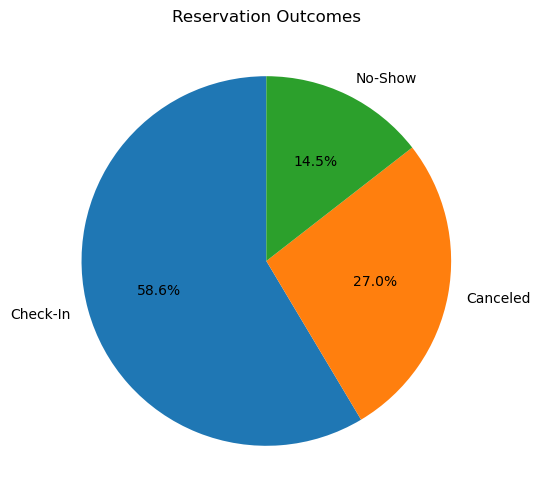

In [14]:
# Pie chart of reservation outcomes
colors = ['#8b0000', '#00008b', '#ff7f00']

plt.figure(figsize=(6, 6))
plt.pie(status_counts, labels=status_counts.index,
         startangle=90, autopct='%1.1f%%')
plt.title('Reservation Outcomes')
plt.show()

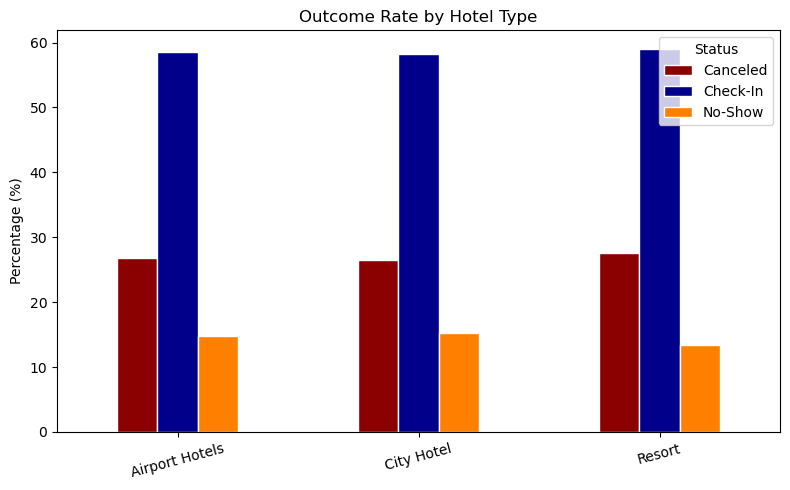

In [13]:
# What % of bookings cancel in each hotel type
hotel_status = pd.crosstab(df['Hotel_Type'], df['Reservation_Status'], normalize='index') * 100

hotel_status.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Hotel Type')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=15)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

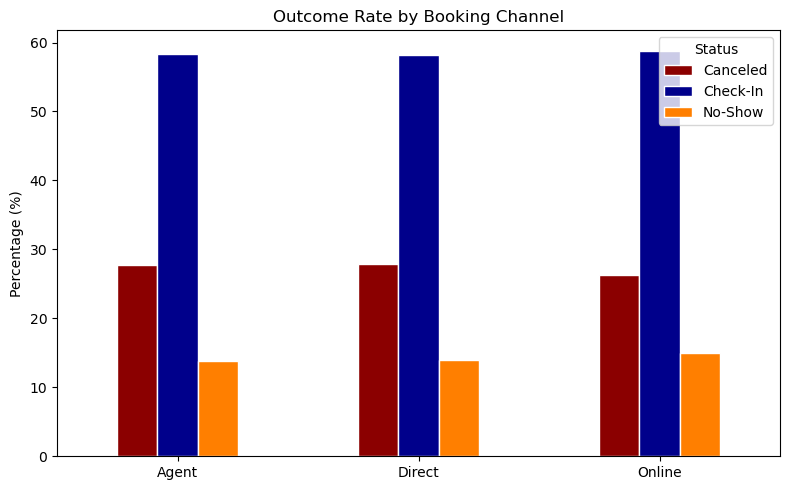

In [105]:
# Does the booking channel affect cancellations
channel_status = pd.crosstab(df['Booking_channel'], df['Reservation_Status'], normalize='index') * 100

channel_status.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Booking Channel')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [109]:
cancel_rates = channel_status['Canceled']
print(cancel_rates)

Booking_channel
Agent     27.777778
Direct    27.933673
Online    26.258764
Name: Canceled, dtype: float64


In [15]:
# Average age, lead time, stay length and room rate per reservation status
df.groupby('Reservation_Status')[['Age', 'Lead_Time_Days', 'Length_of_Stay', 'Room_Rate']].mean().round(2)

,Age,Lead_Time_Days,Length_of_Stay,Room_Rate
Reservation_Status,,,,
Canceled,44.67,107.52,1.83,172.50
Check-In,43.98,109.78,1.78,174.86
No-Show,44.19,113.74,1.80,171.55


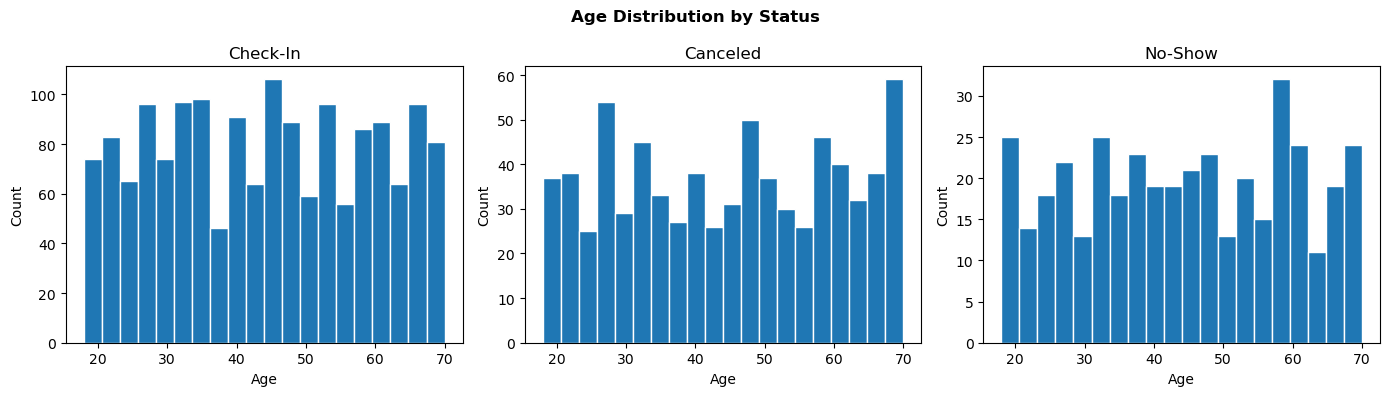

In [35]:
# Age distribution by status
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, status in zip(axes, ['Check-In', 'Canceled', 'No-Show']):
    subset = df[df['Reservation_Status'] == status]['Age']
    ax.hist(subset, bins=20, edgecolor='white')
    ax.set_title(status)
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')

plt.suptitle('Age Distribution by Status', fontweight='bold')
plt.tight_layout()
plt.show()

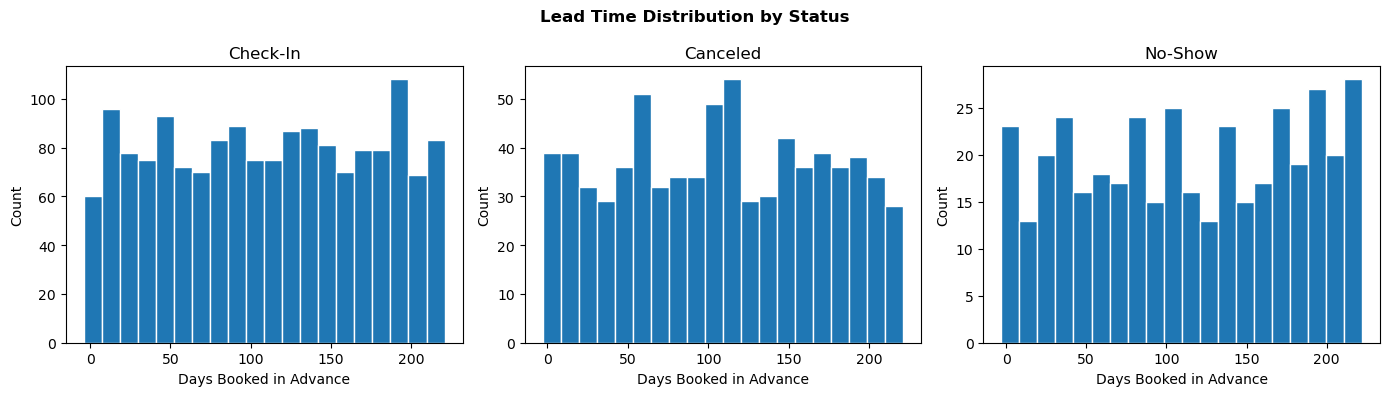

In [37]:
# Lead time histogram for each status separately
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, status in zip(axes, ['Check-In', 'Canceled', 'No-Show']):
    subset = df[df['Reservation_Status'] == status]['Lead_Time_Days']
    ax.hist(subset, bins=20, edgecolor='white')
    ax.set_title(status)
    ax.set_xlabel('Days Booked in Advance')
    ax.set_ylabel('Count')

plt.suptitle('Lead Time Distribution by Status', fontweight='bold')
plt.tight_layout()
plt.show()

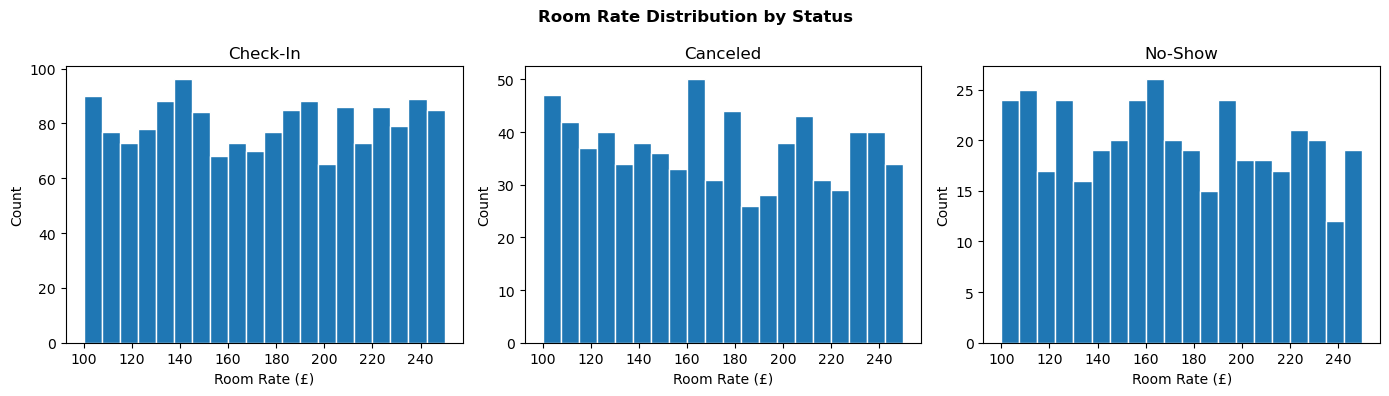

In [39]:
# Room rate histogram for each status separately
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, status in zip(axes, ['Check-In', 'Canceled', 'No-Show']):
    subset = df[df['Reservation_Status'] == status]['Room_Rate']
    ax.hist(subset, bins=20, edgecolor='white')
    ax.set_title(status)
    ax.set_xlabel('Room Rate (£)')
    ax.set_ylabel('Count')

plt.suptitle('Room Rate Distribution by Status', fontweight='bold')
plt.tight_layout()
plt.show()

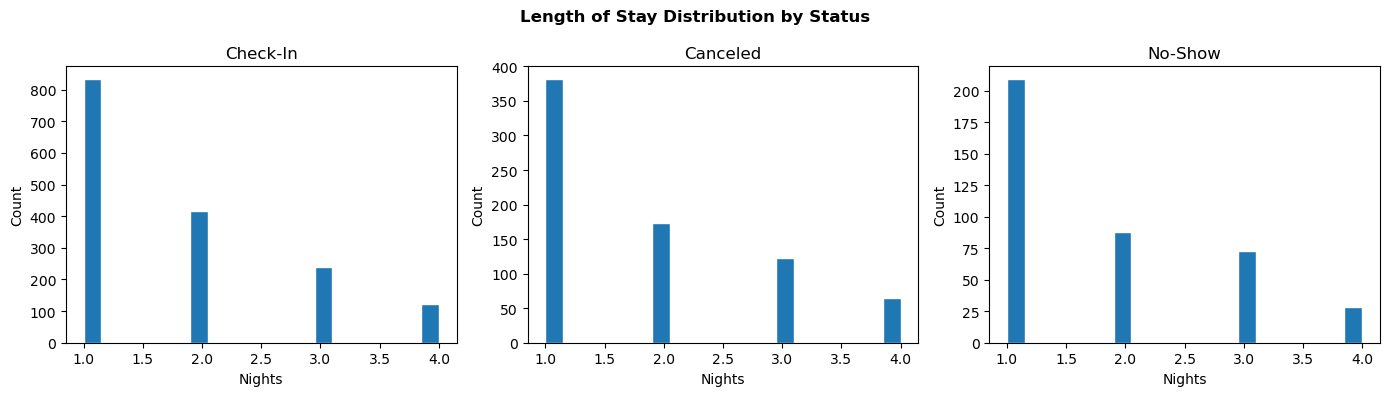

In [41]:
# Length of stay histogram for each status separately
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, status in zip(axes, ['Check-In', 'Canceled', 'No-Show']):
    subset = df[df['Reservation_Status'] == status]['Length_of_Stay']
    ax.hist(subset, bins=20, edgecolor='white')
    ax.set_title(status)
    ax.set_xlabel('Nights')
    ax.set_ylabel('Count')

plt.suptitle('Length of Stay Distribution by Status', fontweight='bold')
plt.tight_layout()
plt.show()

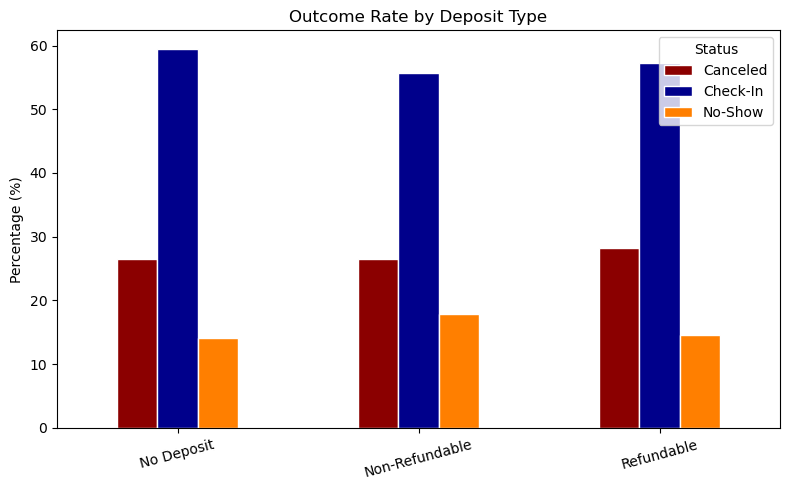

In [45]:
# Does deposit type affect cancellations
deposit_status = pd.crosstab(df['Deposit_type'], df['Reservation_Status'], normalize='index') * 100

deposit_status.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Deposit Type')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=15)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [113]:
print(deposit_status[['Canceled', 'No-Show']])

Reservation_Status   Canceled    No-Show
Deposit_type                            
No Deposit          26.532827  14.053174
Non-Refundable      26.484018  17.808219
Refundable          28.238719  14.556041


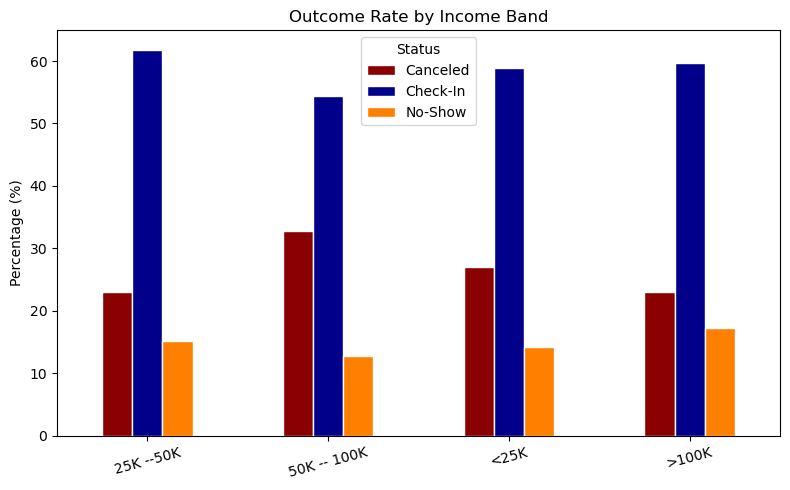

In [47]:
# Does income level affect cancellations
income_status = pd.crosstab(df['Income'], df['Reservation_Status'], normalize='index') * 100

income_status.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Income Band')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=15)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

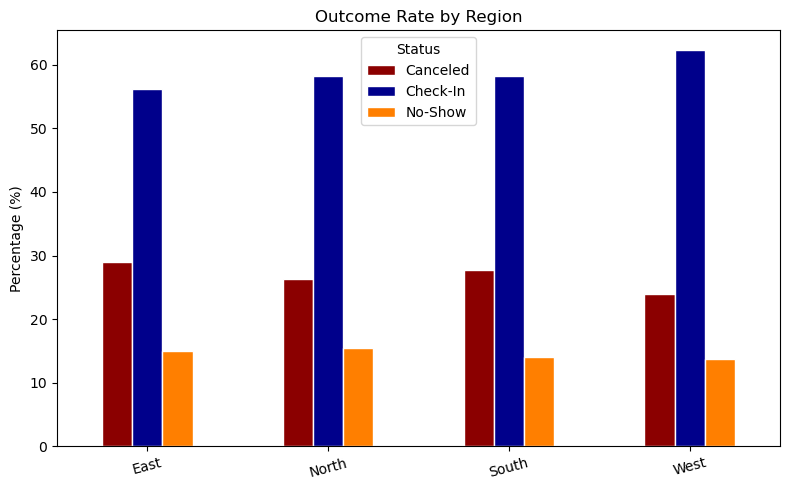

In [51]:
# Does the guest region affect cancellations
region_status = pd.crosstab(df['Country_region'], df['Reservation_Status'], normalize='index') * 100

region_status.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Region')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=15)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

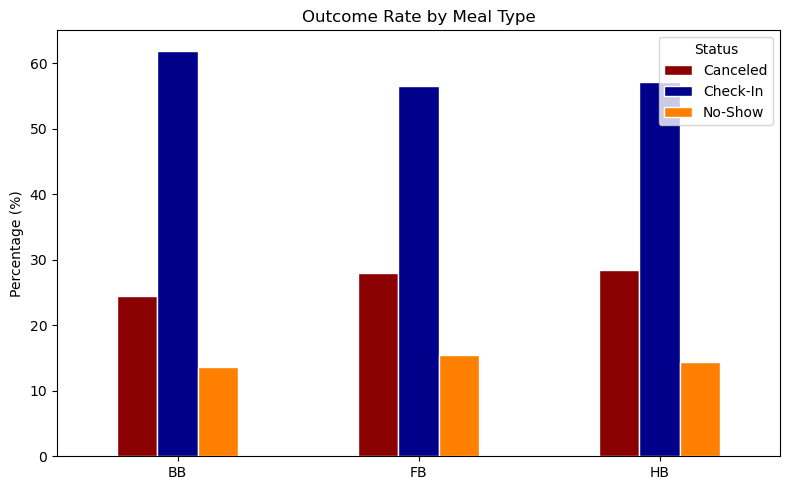

In [53]:
# Does meal plan affect cancellations
meal_status = pd.crosstab(df['Meal_Type'], df['Reservation_Status'], normalize='index') * 100

meal_status.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Meal Type')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

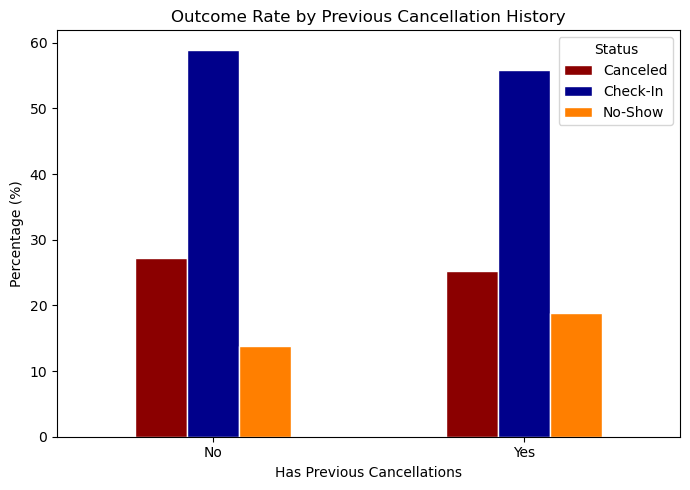

In [55]:
# Do guests with a history of cancelling cancel again?
prev_status = pd.crosstab(df['Previous_Cancellations'], df['Reservation_Status'], normalize='index') * 100

prev_status.plot(kind='bar', figsize=(7, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Previous Cancellation History')
plt.ylabel('Percentage (%)')
plt.xlabel('Has Previous Cancellations')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [123]:
print(prev_status[['Canceled', 'No-Show']])

Reservation_Status       Canceled    No-Show
Previous_Cancellations                      
No                      27.178852  13.878563
Yes                     25.304878  18.902439


In [57]:
# Total revenue for each status
revenue_by_status = df.groupby('Reservation_Status')['Potential_Revenue'].sum()
print(revenue_by_status)

Reservation_Status
Canceled    233825
Check-In    503002
No-Show     122570
Name: Potential_Revenue, dtype: int64


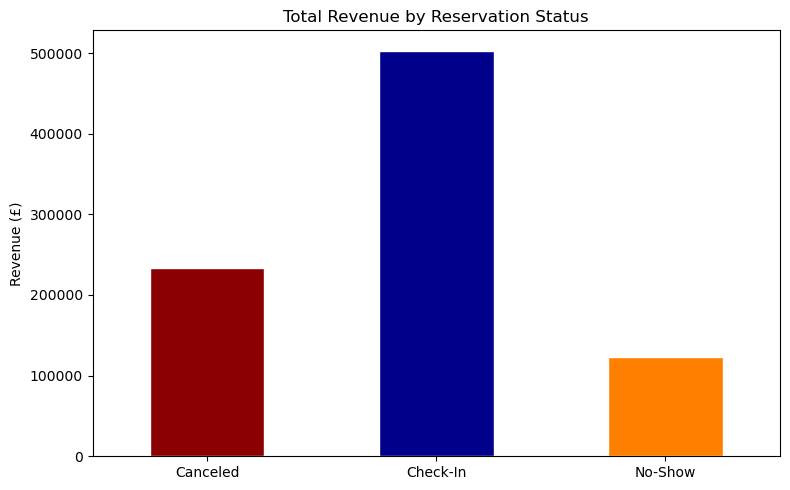

In [61]:
# Bar chart of revenue by reservation status
revenue_by_status = df.groupby('Reservation_Status')['Potential_Revenue'].sum()

revenue_by_status.plot(kind='bar', figsize=(8, 5), color=colors, edgecolor='white')
plt.title('Total Revenue by Reservation Status')
plt.ylabel('Revenue (£)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Hotel_Type
Airport Hotels    127566
City Hotel        116088
Resort            112741
Name: Potential_Revenue, dtype: int64


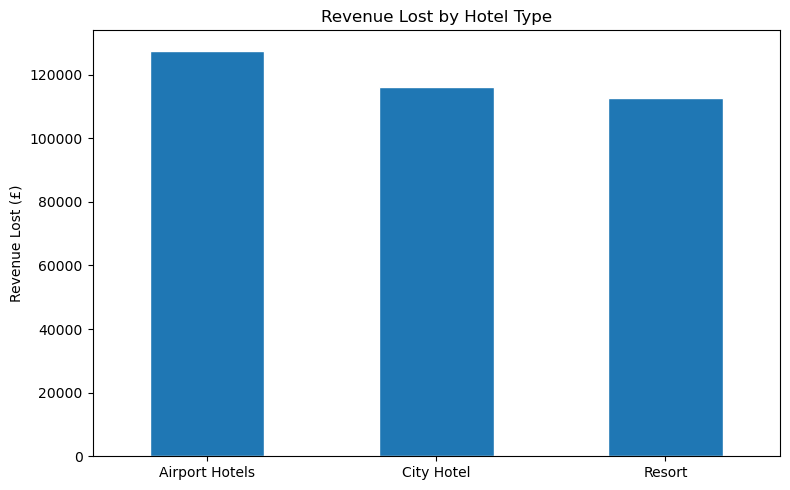

In [65]:
# Filter to only canceled and no-show bookings
lost_df = df[df['Reservation_Status'] != 'Check-In']

lost_by_hotel = lost_df.groupby('Hotel_Type')['Potential_Revenue'].sum()
print(lost_by_hotel)

lost_by_hotel.plot(kind='bar', figsize=(8, 5), edgecolor='white')
plt.title('Revenue Lost by Hotel Type')
plt.ylabel('Revenue Lost (£)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Booking_channel
Agent      54611
Direct    105444
Online    196340
Name: Potential_Revenue, dtype: int64


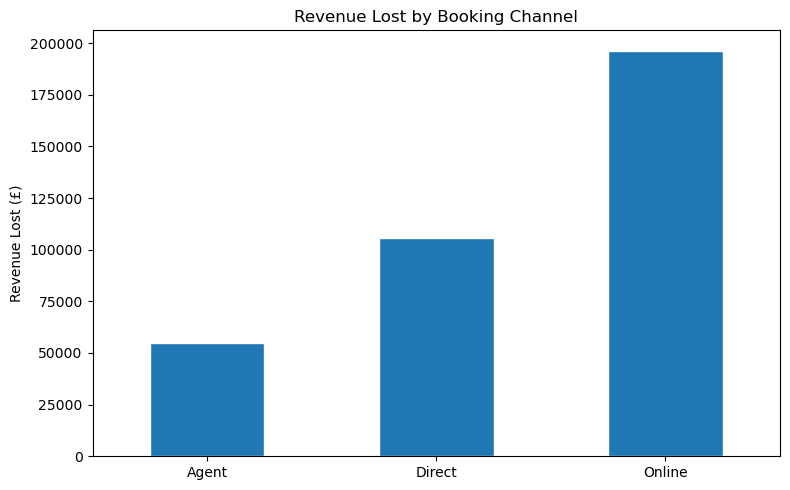

In [67]:
# Revenue lost by booking channel
lost_by_channel = lost_df.groupby('Booking_channel')['Potential_Revenue'].sum()
print(lost_by_channel)

lost_by_channel.plot(kind='bar', figsize=(8, 5), edgecolor='white')
plt.title('Revenue Lost by Booking Channel')
plt.ylabel('Revenue Lost (£)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [71]:
# Do higher discounts lead to more cancellations?
discount_status = pd.crosstab(df['Discount_Rate'], df['Reservation_Status'])
print(discount_status)

Reservation_Status  Canceled  Check-In  No-Show
Discount_Rate                                  
0                        168       403       93
5                        120       252       66
10                       145       329       90
15                        38        67       20
20                       104       246       60
25                        91       147       31
30                        41        83       23
40                        34        83       15


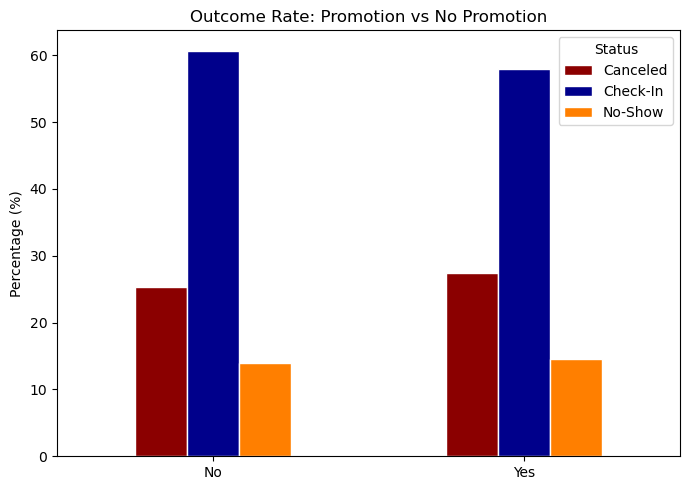

In [75]:
# Does using a promotion affect the outcome
promo_status = pd.crosstab(df['Use_Promotion'], df['Reservation_Status'], normalize='index') * 100

promo_status.plot(kind='bar', figsize=(7, 5), color=colors,  edgecolor='white')
plt.title('Outcome Rate: Promotion vs No Promotion')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [125]:
print(promo_status)

Reservation_Status   Canceled   Check-In    No-Show
Use_Promotion                                      
No                  25.301205  60.692771  14.006024
Yes                 27.482014  57.889688  14.628297


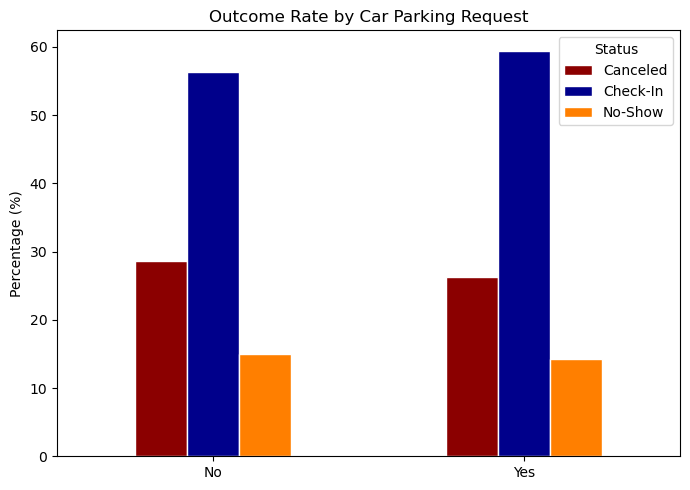

In [81]:
# Do guests who request parking cancel less
parking_status = pd.crosstab(df['Required_Car_Parking'], df['Reservation_Status'], normalize='index') * 100

parking_status.plot(kind='bar', figsize=(7, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate by Car Parking Request')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.tight_layout()
plt.show()

In [83]:
# Extract the month from the check-in date
df['Month'] = df['Expected_checkin'].dt.month_name()
print(df['Month'].value_counts())

Month
October      1178
September     836
November      653
March          16
January        15
August         13
December       13
June            8
May             7
February        6
July            2
April           2
Name: count, dtype: int64


In [87]:
# Extract month and set correct order
df['Month'] = pd.Categorical(df['Expected_checkin'].dt.month_name(),
              categories=['January','February','March','April','May','June',
              'July','August','September','October','November','December'],
              ordered=True)

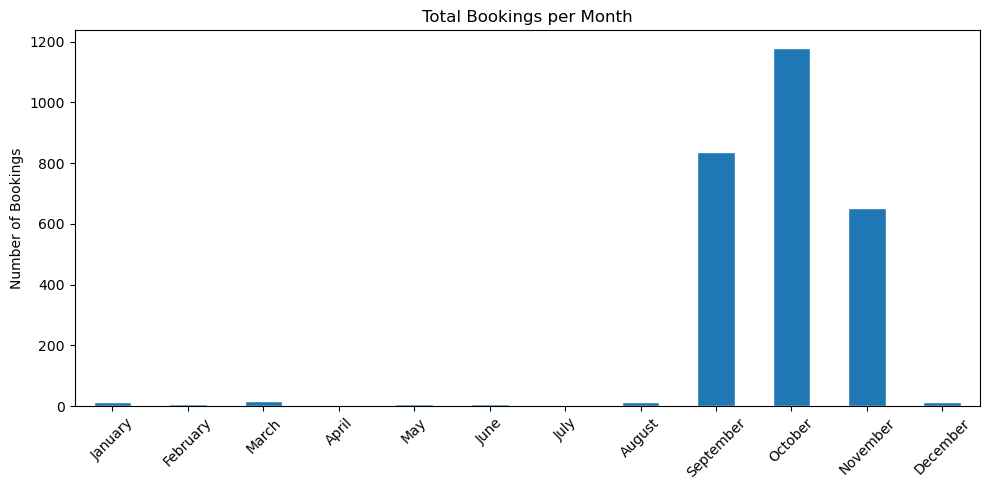

In [93]:
# How many bookings per month
monthly = df.groupby('Month', observed=True)['Reservation_Status'].count()

monthly.plot(kind='bar', figsize=(10, 5), edgecolor='white')
plt.title('Total Bookings per Month')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

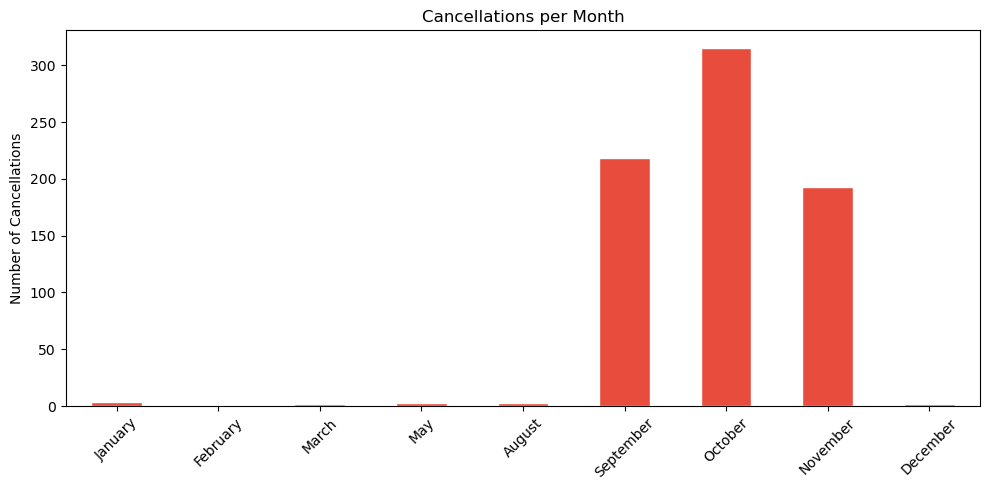

In [95]:
# How many cancellations per month
canceled_df = df[df['Reservation_Status'] == 'Canceled']
canceled_monthly = canceled_df.groupby('Month', observed=True)['Reservation_Status'].count()

canceled_monthly.plot(kind='bar', figsize=(10, 5), color='#e74c3c', edgecolor='white')
plt.title('Cancellations per Month')
plt.ylabel('Number of Cancellations')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [127]:
print(canceled_monthly)

Month
January        4
February       1
March          2
May            3
August         3
September    218
October      315
November     193
December       2
Name: Reservation_Status, dtype: int64


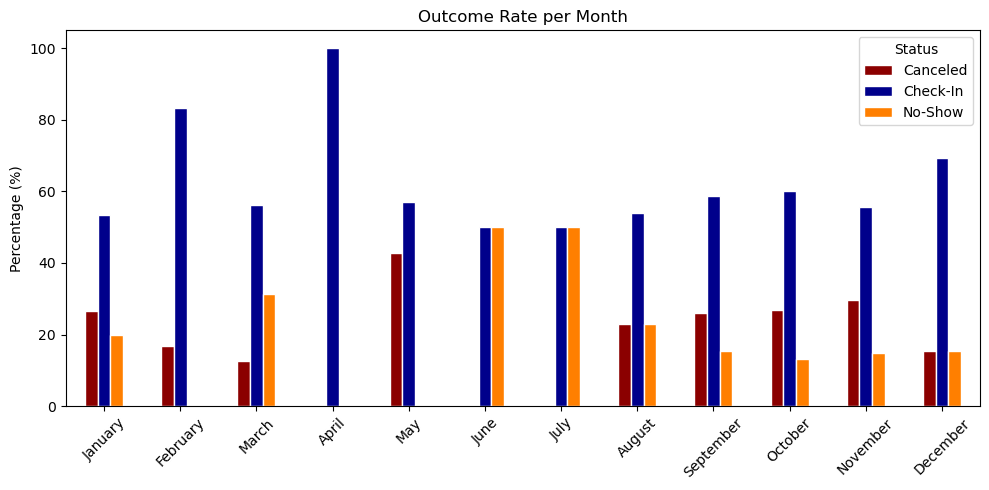

In [99]:
# What's the cancellations per month
monthly_status = pd.crosstab(df['Month'], df['Reservation_Status'], normalize='index') * 100

monthly_status.plot(kind='bar', figsize=(10, 5), color=colors, edgecolor='white')
plt.title('Outcome Rate per Month')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()
plt.show()